<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/fusemachines-2026/phase2/assignment1/tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Phase 2; Week 4
# Statistical Machine Learning: Linear Models
The Goal is to learn about linear models and machine learning pipelines

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Task 1 : Understanding the problem


In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [ ]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [ ]:
print("Shape of X :",X.shape)
print("Shape of y:",y.shape)


Shape of X : (7043, 20)
Shape of y: (7043,)


In [ ]:
X.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [ ]:
X.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### 1. Formulation of Ml Problem
**Feature Space X:** X contains A matrix of Shape (7043, 20):means 7043 individual data and 20 columns or title of data; features are mix of  integer, float and mostly object(string)

**target variable:** y contains the target variable; it the the output that the model need to learn to predict; the data is binary Yes and No;

**Probablity Distrubution:** Bernouli Distrbution is used to model the target because bernouli distibution works with possible 2 outcomes success and failure(churn yes or churn no),

**about loss function:** Since the target follows a Bernoulli distribution, applying Maximum Likelihood
Estimation (MLE) to its likelihood directly derives Binary Cross-Entropyas the loss function not chosen arbitrarily, but mathematically forced by the binary nature of the target.

### 2. Data-Generation Assumptions
> the dataset represents future customers

If violated, the model may learn patters from this customer mix that do not hold for new customers, regions, priccing plans, or time periods,
> Chrun is correctly labeled

If churn labels are wrong or incostient, the model learns the wrong target

> Features were measured before the churn outcome

Columns like tenure, COntract, Monthly charges and payment method must reflect the customer state before churn. If some features are recorded after the cancellation, the model may  learn future information and may overfit


### 3. Source of Uncertanity


In [ ]:
# checking if there is null values in the data
df.isna().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

# here only 3 columsn, SeniorCitizen, tenure and float64 is Numeric,
# linear model or any other ml models requires data to be numeric for better understaing of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()



,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# taking random 5 samples
df.sample(5)

# most of columns are binary yes/no type
# here totalCharges, MonthlyCharges should be float but it is registered as object

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
1666,8388-DMKAE,Female,0,No,No,8,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,174.65,No
6762,9863-JZAIC,Male,0,No,No,35,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,No,Mailed check,55.00,2010.55,Yes
1571,2812-SFXMJ,Male,0,No,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4173,7858-GTZSP,Female,0,No,No,12,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.55,1066.9,No


In [ ]:
print('Churn Distribution')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize = True)*100)

Churn Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


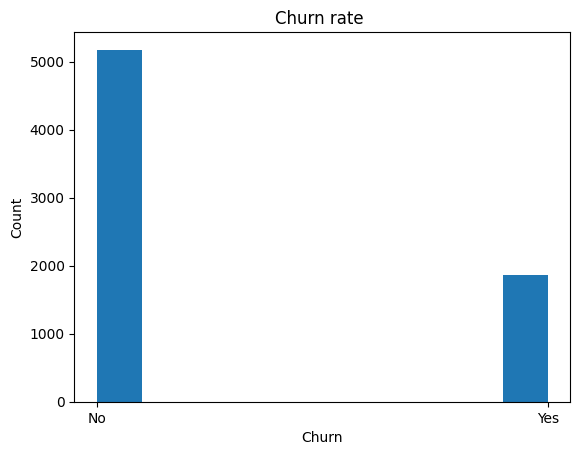

In [ ]:
plt.hist(df['Churn'])
plt.title("Churn rate ")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [ ]:
print("\nUnique values in categorical columns:")
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))



Unique values in categorical columns:

customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No               

### 3. Source of Uncertanity

1. Total Charges has missing values : The column TotalCharges contains blank values that become NaN after conversion to numeric. These rows all have tenure = 0, so they likely represent new customers with no accumulated charges yet.

2. Churn is imbalancced: Only about 27% of customers churned. THis  means accuracy can be misleading, because if model just preddict "NO churn" everytime the accuraccy will be 73%


4. Some categorical values are structural, not ordinary categories.
Columns such as OnlineSecurity, OnlineBackup, TechSupport, StreamingTV, and StreamingMovies contain values like "No internet service". These should not be treated as missing values3. Tenure has zero values: The tenure column contains customers with tenure == 0. These customers may not have had enough time to churn, so their Churn = No label may be uncertain or censored.
 because they describe customers who do not have internet service.








## Task 2: Classification Experiment Who Will Churn?

Goal : goal is to find the best linear classifier for predicting churn.

1. Try Multiplee models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [ ]:
X = X.drop(['customerID'],axis=1)

In [ ]:
# Encode categorical
X = pd.get_dummies(X, drop_first=True)


In [ ]:
# train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=36)
# stratify=y is used in the train_test_split function to ensure that the split between your training and
# testing sets preserves the same proportions of class labels found in your original data

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler

# scale
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_test = le.transform(y_test)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(5634, 6559)
(1409, 6559)


In [ ]:
y_test

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss

In [ ]:
models = {
    'logistic': LogisticRegression(max_iter = 1000, solver= 'lbfgs'),
    'ridge': RidgeClassifier(alpha=1.0),
    'sgd': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

}

In [ ]:


results = {}

for name, model in models.items():
    # train
    model.fit(X_train_scaled, y_train)

    # predict
    y_pred = model.predict(X_test_scaled)

    # initialize metrics that don't require probabilities
    current_model_results = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    }

    # checking if the model has predict_proba before calculating ROC-AUC and Log Loss
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        current_model_results['ROC-AUC'] = roc_auc_score(y_test, y_pred_proba)
        current_model_results['Log Loss'] = log_loss(y_test, y_pred_proba)
    else:
        # For models without predict_proba, these metrics are not applicable
        current_model_results['ROC-AUC'] = np.nan
        current_model_results['Log Loss'] = np.nan

    results[name] = current_model_results

# Comparison table
results_df = pd.DataFrame(results).T
print(results_df.round(3))

          Accuracy  Precision  Recall     F1  ROC-AUC  Log Loss
logistic     0.770      0.647   0.440  0.524    0.808     0.754
ridge        0.665      0.445   0.664  0.533      NaN       NaN
sgd          0.747      0.735   0.185  0.296    0.793     7.336


In [ ]:
# here the best model seems to be 